In [1]:
import xarray as xr
import ndsl.dsl.gt4py_utils as gt_utils
from ndsl import GridSizer, Quantity, QuantityFactory, TileCommunicator, TilePartitioner, NullComm, SubtileGridSizer
import ndsl.constants as constants

from pyshield.radiation import RTE_RRTMGPState, RTE_RRTMGPConfig, RTE_RRTMGPDriver
from pyshield.physics_state import SurfaceState
from pyshield._config import PHYSICS_PACKAGES, PhysicsConfig
import numpy as np
import matplotlib.pyplot as plt
import datetime

2025-09-22 14:40:37|INFO|rank 0|ndsl.logging:Constant selected: ConstantVersions.UFS


In [2]:
ds = xr.open_dataset("RESTART/restart_physics_state_0.nc")
ds2 = xr.open_dataset("RESTART/restart_dycore_state_0.nc")

In [3]:
schemes = PHYSICS_PACKAGES
nx_tile=20
ny_tile=20
nz=79
n_halo=3
date = datetime.datetime(2020, 1, 1, 12, tzinfo=datetime.timezone.utc)

In [4]:
rank = 0

comm = NullComm(rank, 1)
communicator = TileCommunicator.from_layout(comm=comm, layout=(1,1))

sizer = SubtileGridSizer.from_tile_params(
    nx_tile=nx_tile,
    ny_tile=ny_tile,
    nz=nz,
    n_halo=n_halo,
    extra_dim_lengths={},
    layout=(1,1),
    tile_partitioner=communicator.partitioner.tile,
    tile_rank=communicator.tile.rank,
)
quantity_factory = QuantityFactory.from_backend(
    sizer, backend="numpy"
)

In [5]:
from ndsl import StencilFactory, CompilationConfig, StencilConfig, GridIndexing

In [6]:
comconf = CompilationConfig()
comconf.validate_args = False
sconf = StencilConfig(compilation_config=comconf)
grid_indexing = GridIndexing.from_sizer_and_communicator(sizer=sizer, comm=communicator)
stencil_factory = StencilFactory(config=sconf, grid_indexing=grid_indexing, comm=comm)

In [7]:
from ndsl.grid import (
    AngleGridData,
    ContravariantGridData,
    DampingCoefficients,
    DriverGridData,
    GridData,
    HorizontalGridData,
    MetricTerms,
    VerticalGridData,
)
from pathlib import Path

In [8]:
metric_terms = MetricTerms(
    quantity_factory=quantity_factory,
    communicator=communicator,
    grid_type=4,
    eta_file="eta79.nc",
)
horizontal_data = HorizontalGridData.new_from_metric_terms(metric_terms)
vertical_data = VerticalGridData.new_from_metric_terms(metric_terms)
contravariant_data = ContravariantGridData.new_from_metric_terms(metric_terms)
angle_data = AngleGridData.new_from_metric_terms(metric_terms)
grid_data = GridData(
    horizontal_data=horizontal_data,
    vertical_data=vertical_data,
    contravariant_data=contravariant_data,
    angle_data=angle_data,
)

In [9]:
grid_data.lon_agrid.field[:] = grid_data.lon.field[:-1,:-1]
grid_data.lat_agrid.field[:] = grid_data.lat.field[:-1,:-1]

In [10]:
conf = PhysicsConfig
radconf = RTE_RRTMGPConfig(
    deltsw = 3600.0,
    delt_rad = 3600.0,
    date=date,
    fhswr=1.0,
    fhlwr=1.0,
    isolar=10,
    icmphys=4,
    ico2flg=0,
    ioznflg=1,
    ictmflg=-1,
    ialbflg=-1,
    iemsflg=0,
    ldisable_radiation_quasi_sea_ice=False,
    solar_constant_file=Path("global_solarconstant_noaa_an.txt"),
    input_dir=Path("../../test_data/"),
    aerosol_file=Path("../../test_data/"),
    sollat=0.0,
    nstp=6,
    ivflip=1,
    lcnorm=False,
    lcrick=False,
    gfs_cloud_overlap=False,
)

In [11]:
from pyshield.stencils.physics import calc_sigma

In [12]:
sigma = calc_sigma(grid_data.ak.data, grid_data.bk.data, 0)
gridlon = grid_data.lon_agrid
gridlat = grid_data.lat_agrid

In [13]:
rad = RTE_RRTMGPDriver(config=radconf, gridlon=gridlon, gridlat=gridlat, sigma=sigma[::-1], quantity_factory=quantity_factory, stencil_factory=stencil_factory)

2025-09-22 14:40:37|INFO|rank 0|ndsl.logging: - Using new fixed solar constant = 1360.8
2025-09-22 14:40:37|INFO|rank 0|ndsl.logging:Using Constant Albedo 0.06
2025-09-22 14:40:37|INFO|rank 0|ndsl.logging:Enable radiation quasi-sea-ice
2025-09-22 14:40:37|INFO|rank 0|ndsl.logging:Using Fixed Surface Emissivity 0.97 for lw


/Users/oliverelbert/anaconda3/envs/pyshield/lib/python3.11/site-packages/gt4py/cartesian/gtc/passes/gtir_pipeline.py:48: UserWarning: `coszenm` may be uninitialized.
  result = step(result)


In [14]:
state = RTE_RRTMGPState.init_zeros(quantity_factory, np)
sstate = SurfaceState.init_zeros(quantity_factory)
type(state.prsi)

ndsl.quantity.quantity.Quantity

In [15]:
prsi = ds.prsi.values[3:-4,3:-4,::-1] # level pressure
prsl = (prsi[:,:,1:] - prsi[:,:,:-1]) / np.log(prsi[:,:,1:] / prsi[:,:,:-1])
pt = ds.pt.values[3:-4,3:-4,-2::-1] # Layer temperature
delp = ds.delp.values[3:-4,3:-4,-2::-1]
delz = -1.* ds.delz.values[3:-4,3:-4,-2::-1]
dz = -1.* ds.dz.values[3:-4,3:-4,-2::-1]
qvap = ds.qvapor.values[3:-4,3:-4,-2::-1]
qliq = ds.qliquid.values[3:-4,3:-4,-2::-1]
qice = ds.qice.values[3:-4,3:-4,-2::-1]
qcld = ds.qcld.values[3:-4,3:-4,-2::-1]
phii = ds.phii.values[3:-4,3:-4,::-1]
ptlev = np.zeros_like(prsi)
ptlev[:,:,1:-1] = pt[:,:,:-1] + (pt[:,:,1:] - pt[:,:,:-1]) * (np.log(prsi[:,:,1:-1]) - np.log(prsl[:,:,:-1])) / (np.log(prsl[:,:,1:]) - np.log(prsl[:,:,:-1]))
ptlev[:,:,-1] = pt[:,:,-1]
ptlev[:,:,0] = pt[:,:,0]
qo3mr = ds.qo3mr.values[3:-4,3:-4,-2::-1]
tskin = ptlev[:,:,-1]

In [16]:
state.prsi.view[:] = prsi
state.prsl.view[:] = prsl
state.tlyr.view[:] = pt
state.tlvl.view[:] = ptlev
state.tsfc.view[:] = tskin
state.qvapor.view[:] = qvap
state.qliquid.view[:] = qliq
state.qice.view[:] = qice
state.qcld.view[:] = qcld
state.qo3mr.view[:] = qo3mr

In [17]:
rad.step_radiation(state, sstate, date)

In [18]:
import matplotlib.pyplot as plt

In [19]:
levels = np.arange(nz+1)

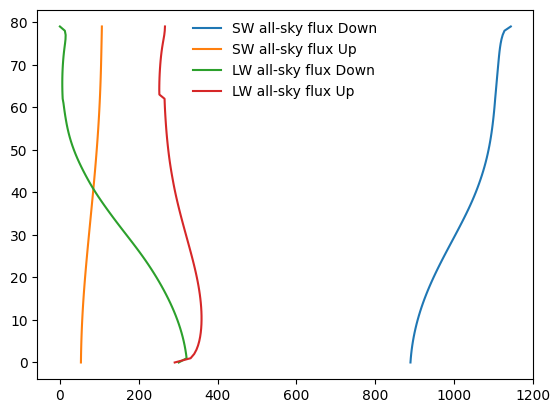

In [20]:
plt.plot(state.fswd.view[0,0,:], levels, label="SW all-sky flux Down")
plt.plot(state.fswu.view[0,0,:], levels, label="SW all-sky flux Up")
plt.plot(state.flwd.view[0,0,:], levels, label="LW all-sky flux Down")
plt.plot(state.flwu.view[0,0,:], levels, label="LW all-sky flux Up")
plt.legend(frameon=False)

In [21]:
newdate = date + datetime.timedelta(seconds=radconf.delt_rad)

In [22]:
%%time
rad.step_radiation(state, sstate, newdate)

CPU times: user 1.2 s, sys: 1.52 s, total: 2.72 s
Wall time: 1.22 s


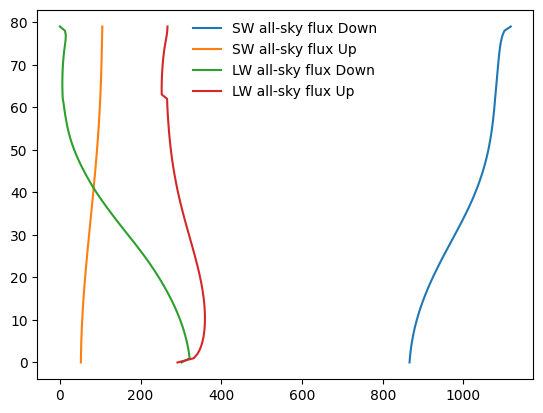

In [23]:
plt.plot(state.fswd.view[0,0,:], levels, label="SW all-sky flux Down")
plt.plot(state.fswu.view[0,0,:], levels, label="SW all-sky flux Up")
plt.plot(state.flwd.view[0,0,:], levels, label="LW all-sky flux Down")
plt.plot(state.flwu.view[0,0,:], levels, label="LW all-sky flux Up")
plt.legend(frameon=False)

In [24]:
print(newdate)

2020-01-01 13:00:00+00:00


In [25]:
%%time
for i in range(10):
    newdate = newdate + datetime.timedelta(seconds=radconf.delt_rad)
    print(newdate)
    rad.step_radiation(state, sstate, newdate)

2020-01-01 14:00:00+00:00
2020-01-01 15:00:00+00:00
2020-01-01 16:00:00+00:00
2020-01-01 17:00:00+00:00
2020-01-01 18:00:00+00:00
2020-01-01 19:00:00+00:00
2020-01-01 20:00:00+00:00
2020-01-01 21:00:00+00:00
2020-01-01 22:00:00+00:00
2020-01-01 23:00:00+00:00
CPU times: user 10.2 s, sys: 2.29 s, total: 12.5 s
Wall time: 12.3 s


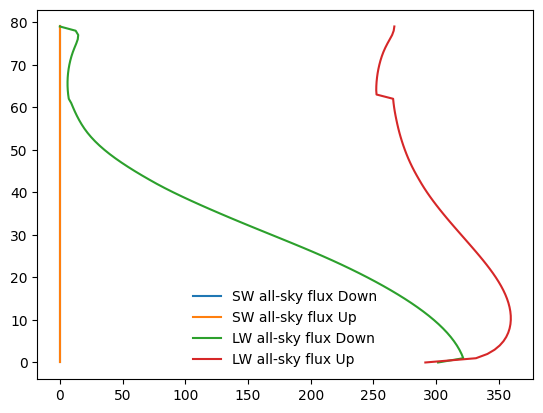

In [26]:
plt.plot(state.fswd.view[0,0,:], levels, label="SW all-sky flux Down")
plt.plot(state.fswu.view[0,0,:], levels, label="SW all-sky flux Up")
plt.plot(state.flwd.view[0,0,:], levels, label="LW all-sky flux Down")
plt.plot(state.flwu.view[0,0,:], levels, label="LW all-sky flux Up")
plt.legend(frameon=False)

In [27]:
state.mu0.field[:]

array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0.